# Notebook 04 — Visualización de resultados y figuras finales

**Notebook:** `04_results_visualization.ipynb`  
**TFM:** Bioinformática estructural — Familia RAS  
**Objetivo:** Este notebook es el **último del pipeline** y tiene como objetivo convertir todos los datos procesados en los hitos anteriores en figuras publicables, tablas de resultados estructuradas y vistas 3D interactivas que permitan comunicar los hallazgos del análisis comparativo estructural de los parálogos RAS (KRAS, HRAS, NRAS).

---

Los notebooks anteriores han generado los siguientes ficheros en `data/processed/`:

| Fichero | Contenido | Generado en |
|---|---|---|
| `cosmic_curated.csv` | Mutaciones somáticas de COSMIC filtradas y curadas | Notebook 01 |
| `position_map.csv` | Mapa de equivalencias posicionales en el MSA KRAS-HRAS-NRAS | Notebook 02 |
| `master_features.csv` | DataFrame maestro con todas las features estructurales y mutacionales por posición y gen | Notebook 03 |
| `recurrent_positions.csv` | Posiciones recurrentemente mutadas en ≥2 parálogos RAS | Notebook 03 |

## Estructura del notebook

1. **Carga de datos** — Lectura de los ficheros CSV procesados
2. **Figuras 2D** — Heatmap, clustermap y scatter SASA-distancia 
3. **Vistas 3D interactivas** — Visualizaciones moleculares individuales y comparativa con py3Dmol
4. **Tablas de resultados** — Tres tablas con los hallazgos más relevantes para la memoria del TFM

## Dependencias

```
pandas, numpy, matplotlib, seaborn, py3Dmol, biopython, tfm_ras
```

> **Nota:** Este notebook debe ejecutarse con el entorno conda activado según las
> instrucciones del notebook `00_setup.ipynb`. Todos los ficheros de salida se guardan
> en el directorio `figures/` en la raíz del proyecto.

---
## Sección 1: Importaciones y configuración del entorno

In [21]:
# ============================================================
# CHUNK 1.1: Importaciones y configuración general
# ============================================================

# -- Biblioteca estándar de Python --
from pathlib import Path   # Manejo de rutas del sistema de ficheros de forma orientada a objetos
import sys                 # Acceso a información del intérprete Python (versión, path, etc.)
import warnings            # Control de advertencias en tiempo de ejecución

# -- Bibliotecas de análisis de datos --
import pandas as pd        # Manipulación de DataFrames tabulares (tablas con etiquetas)
import numpy as np         # Operaciones numéricas vectorizadas sobre arrays

# -- Bibliotecas de visualización --
import matplotlib.pyplot as plt   # Motor de renderizado de figuras; base de toda la visualización
import seaborn as sns             # Figuras estadísticas de alto nivel construidas sobre matplotlib

# -- Visualización 3D interactiva --
# py3Dmol genera código JavaScript para el visor molecular 3Dmol.js (WebGL).
# No necesita servidor ni instalación en el navegador; el HTML resultante es auto-contenido.
# Referencia: https://3dmol.csb.pitt.edu/
import py3Dmol

# -- Módulos del paquete del TFM --
# Añadimos la raíz del proyecto al sys.path para que Python encuentre el paquete tfm_ras
# cuando se ejecuta el notebook desde el directorio notebooks/
sys.path.insert(0, str(Path("..").resolve()))  # Sube un nivel: de notebooks/ a la raíz del proyecto

from tfm_ras.config import project_root  
from tfm_ras.visualization import (      
    heatmap_mutations_per_position,       
    clustermap_top_positions,           
    scatter_sasa_distance,               
    view_3d_with_hotspots,               
    comparative_3d_view,                  
    compare_states_3d,
    compare_isoforms_3d,
    STRUCTURE_REGISTRY,
    HOTSPOTS,
    verify_structure_registry
)

# Suprimimos las advertencias de matplotlib sobre DPI para mantener la salida limpia
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Configuración global de matplotlib para figuras de calidad de publicación
plt.rcParams["figure.dpi"] = 120          # Resolución de visualización inline (alta calidad en Jupyter)
plt.rcParams["savefig.dpi"] = 300         # Resolución al guardar ficheros (estándar de publicación)
plt.rcParams["font.size"] = 10            # Tamaño de fuente base para todos los elementos de figura
plt.rcParams["axes.titlesize"] = 11       # Tamaño de fuente para títulos de paneles
plt.rcParams["axes.labelsize"] = 10       # Tamaño de fuente para etiquetas de ejes

print(f"Python {sys.version}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")
print(f"py3Dmol {py3Dmol.__version__}")
print(f"Raíz del proyecto: {project_root()}")

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:58:53) [Clang 19.1.7 ]
pandas 3.0.3 | numpy 2.4.6 | seaborn 0.13.2
py3Dmol 2.5.4
Raíz del proyecto: /Users/rachi/Desktop/TFM/tfm_ras_mutations


In [22]:
# ============================================================
# CHUNK 1.2: Definición de rutas del proyecto
# ============================================================

# Obtenemos la ruta raíz del proyecto de forma portable
# (funciona igual independientemente del directorio de trabajo actual)
ROOT = project_root()  # Path absoluto a la raíz del proyecto (p. ej. /home/usuario/plantilla_v2)

# Directorios principales que se usarán en este notebook
PROCESSED_DIR = ROOT / "data" / "processed"    # Directorio con los CSV generados por notebooks anteriores
PDB_DIR       = ROOT / "data" / "external" / "pdb"  # Directorio con los ficheros .pdb de las estructuras
FIGURES_DIR   = ROOT / "figures"                # Directorio de salida para todas las figuras del TFM

# Creamos el directorio de figuras si no existe
# mkdir(parents=True): crea también directorios intermedios si son necesarios
# mkdir(exist_ok=True): no falla si el directorio ya existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Verificamos que los ficheros de entrada existen antes de continuar
input_files = {
    "cosmic_curated": PROCESSED_DIR / "cosmic_curated.csv",
    "position_map": PROCESSED_DIR / "position_map.csv",
    "master_features": PROCESSED_DIR / "master_features.csv",
    "recurrent_positions": PROCESSED_DIR / "recurrent_positions.csv",
}

print("Verificando ficheros de entrada:")
for name, path in input_files.items():
    # path.exists() devuelve True si el fichero existe en disco
    status = "OK" if path.exists() else "FALTA"
    print(f"  [{status}] {path.name}")

print(f"\nDirectorio de figuras: {FIGURES_DIR}")
print(f"Directorio de PDBs:    {PDB_DIR}")

Verificando ficheros de entrada:
  [OK] cosmic_curated.csv
  [OK] position_map.csv
  [OK] master_features.csv
  [OK] recurrent_positions.csv

Directorio de figuras: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures
Directorio de PDBs:    /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/external/pdb


---
## Sección 2: Carga de los datos procesados

Los cuatro ficheros CSV son el resultado acumulado de los tres notebooks anteriores.
Cada uno representa un nivel distinto de abstracción del análisis:

- **`cosmic_curated`**: nivel de mutación individual (gen × posición × cambio aminoacídico)
- **`position_map`**: nivel de columna del MSA (equivalencias entre las tres isoformas)
- **`master_features`**: nivel de feature por posición y gen (datos estructurales + mutacionales)
- **`recurrent_positions`**: nivel de posición recurrente (filtrado por frecuencia y recurrencia)

In [23]:
# ============================================================
# CHUNK 2.1: Carga de cosmic_curated.csv
# ============================================================

# Este CSV contiene una fila por cada combinación única de (gen, posición, cambio aminoacídico)
# con el número de muestras tumorales COSMIC que presentan esa mutación.
# Es el resultado del Hito 1: filtrado y curación de los datos COSMIC crudos.
cosmic_curated = pd.read_csv(
    input_files["cosmic_curated"],
    # dtype explícito para las columnas críticas evita problemas de inferencia automática
    dtype={
        "gene": str,        # Símbolo del gen (KRAS, HRAS, NRAS)
        "position": int,    # Posición UniProt del residuo mutado
        "wt_aa": str,       # Aminoácido wild-type (original)
        "mut_aa": str,      # Aminoácido mutado
        "hgvs_p": str,      # Notación HGVS del cambio (p. ej. "p.G12D")
    },
)

print(f"cosmic_curated: {len(cosmic_curated):,} filas × {cosmic_curated.shape[1]} columnas")
print(f"Genes presentes: {cosmic_curated['gene'].unique().tolist()}")
print(f"Columnas: {cosmic_curated.columns.tolist()}")
cosmic_curated.head(3)  # Mostramos las primeras 3 filas para inspección visual

cosmic_curated: 469 filas × 10 columnas
Genes presentes: ['KRAS', 'HRAS', 'NRAS']
Columnas: ['gene', 'uniprot_id', 'position', 'wt_aa', 'mut_aa', 'hgvs_p', 'sample_count', 'tumor_types', 'primary_tissues', 'cosmic_version']


,gene,uniprot_id,position,wt_aa,mut_aa,hgvs_p,sample_count,tumor_types,primary_tissues,cosmic_version
0,KRAS,P01116,12,G,D,p.G12D,4697,Ewing_sarcoma-peripheral_primitive_neuroectode...,NS | autonomic_ganglia | biliary_tract | bone ...,v104
1,KRAS,P01116,12,G,V,p.G12V,3625,Wilms_tumour | aberrant_crypt_foci | adenoma |...,NS | autonomic_ganglia | biliary_tract | breas...,v104
2,KRAS,P01116,13,G,D,p.G13D,1716,NS | aberrant_crypt_foci | adenoma | angiosarc...,NS | biliary_tract | breast | cervix | endomet...,v104


In [24]:
# ============================================================
# CHUNK 2.2: Carga de position_map.csv
# ============================================================

# Este CSV contiene una fila por cada columna del alineamiento múltiple de secuencias (MSA)
# de los tres parálogos RAS. Cada fila mapea una posición en el MSA a las posiciones
# equivalentes en las secuencias individuales de KRAS, HRAS y NRAS.
# Columnas clave:
#   msa_position  → índice 1-based en el alineamiento
#   kras_position → posición en la secuencia KRAS (NaN si hay gap)
#   hras_position → posición en la secuencia HRAS (NaN si hay gap)
#   nras_position → posición en la secuencia NRAS (NaN si hay gap)
#   conserved     → True si el mismo aminoácido aparece en los tres parálogos
position_map = pd.read_csv(input_files["position_map"])

print(f"position_map: {len(position_map):,} filas × {position_map.shape[1]} columnas")
print(f"Posiciones MSA totales: {position_map['msa_position'].max()}")
print(f"Posiciones conservadas: {position_map['conserved'].sum()} "
      f"({position_map['conserved'].mean()*100:.1f}%)")
position_map.head(3)

position_map: 189 filas × 8 columnas
Posiciones MSA totales: 189
Posiciones conservadas: 152 (80.4%)


,msa_position,kras_position,hras_position,nras_position,kras_aa,hras_aa,nras_aa,conserved
0,1,1,1,1,M,M,M,True
1,2,2,2,2,T,T,T,True
2,3,3,3,3,E,E,E,True


In [25]:
# ============================================================
# CHUNK 2.3: Carga de master_features.csv
# ============================================================

# Este es el DataFrame central del análisis. Contiene una fila por cada combinación
# (gen × posición MSA × estado) con todas las features computadas en el Hito 3:
#
#   gene                       → símbolo del gen RAS
#   state                      → estado GTP/GDP (GTP=activo, GDP=inactivo)
#   uniprot_position           → posición en la secuencia UniProt del gen
#   msa_position               → posición en el alineamiento múltiple
#   aa_wt                      → aminoácido wild-type en esa posición
#   total_samples              → suma de muestras COSMIC con mutación en esa posición
#   top_mutation               → mutación más frecuente en esa posición
#   sasa_abs                   → accesibilidad absoluta al solvente (Ångströms)
#   sasa_rel                   → accesibilidad relativa al solvente
#   dist_active_site_angstrom  → distancia al sitio activo más cercano (Ångströms)
#   shannon_entropy            → entropía de Shannon de la posición en el MSA
#   recurrent                  → True si la posición está mutada en ≥2 parálogos
#   n_members_mutated          → número de parálogos con mutaciones en esa posición
master_features = pd.read_csv(
    input_files["master_features"],
    # La columna 'recurrent' es booleana; la leemos explícitamente para evitar
    # que pandas la interprete como cadena de texto ("True"/"False")
    dtype={"recurrent": bool},
)

print(f"master_features: {len(master_features):,} filas × {master_features.shape[1]} columnas")
print(f"Columnas disponibles: {master_features.columns.tolist()}")

# NOTA: total_samples y recurrent son propiedades de (gen, posición) y de
# (posición) respectivamente — NO dependen del estado GTP/GDP. Como cada
# combinación aparece 2 veces en la tabla (una por estado), contar
# directamente sobre las 996 filas duplica los resultados. Filtramos a un
# solo estado (GTP) para evitar el doble conteo.

# Combinaciones únicas (gen, posición) con al menos una mutación
n_gene_pos_mutated = master_features.query("state == 'GTP'")['total_samples'].gt(0).sum()
print(f"Combinaciones gen-posición con mutaciones: {n_gene_pos_mutated}")

# Posiciones MSA únicas recurrentes (independiente de gen y estado)
n_recurrent = master_features.loc[master_features['recurrent'], 'msa_position'].nunique()
print(f"Posiciones recurrentes (≥2 parálogos): {n_recurrent}")

master_features.head(3)

master_features: 996 filas × 13 columnas
Columnas disponibles: ['gene', 'state', 'uniprot_position', 'msa_position', 'aa_wt', 'total_samples', 'top_mutation', 'sasa_abs', 'sasa_rel', 'dist_active_site_angstrom', 'shannon_entropy', 'recurrent', 'n_members_mutated']
Combinaciones gen-posición con mutaciones: 263
Posiciones recurrentes (≥2 parálogos): 6


,gene,state,uniprot_position,msa_position,aa_wt,total_samples,top_mutation,sasa_abs,sasa_rel,dist_active_site_angstrom,shannon_entropy,recurrent,n_members_mutated
0,KRAS,GTP,1,1,M,0,NaN,110.864342,0.494930,26.142447,-0.0,False,0
1,KRAS,GTP,2,2,T,1,p.T2I,23.067446,0.134113,24.359534,-0.0,False,0
2,KRAS,GTP,3,3,E,1,p.E3K,24.389114,0.109368,20.443204,-0.0,False,0


In [26]:
# ============================================================
# CHUNK 2.4: Carga de recurrent_positions.csv
# ============================================================

# Este CSV contiene solo las posiciones MSA que están recurrentemente mutadas
# en ≥2 parálogos RAS, con el umbral de mínimo 10 muestras por parálogo.
# Representa el conjunto de hotspots conservados funcionalmente entre isoformas.
# Columnas clave:
#   msa_position     → posición en el alineamiento
#   n_members_mutated → número de parálogos con mutaciones (2 o 3)
#   total_samples    → suma de muestras en todos los parálogos
#   kras_samples     → muestras COSMIC con mutación en esa posición de KRAS
#   hras_samples     → muestras COSMIC con mutación en esa posición de HRAS
#   nras_samples     → muestras COSMIC con mutación en esa posición de NRAS
#   top_mutations    → las mutaciones más frecuentes separadas por '|'
recurrent_positions = pd.read_csv(input_files["recurrent_positions"])

print(f"recurrent_positions: {len(recurrent_positions):,} posiciones recurrentes")
print(f"Hotspots en los 3 parálogos: "
      f"{recurrent_positions['n_members_mutated'].ge(3).sum()}")
print(f"Total de muestras cubierto: "
      f"{recurrent_positions['total_samples'].sum():,}")
recurrent_positions.head(6)

recurrent_positions: 6 posiciones recurrentes
Hotspots en los 3 parálogos: 3
Total de muestras cubierto: 18,078


,msa_position,kras_pos,hras_pos,nras_pos,n_members_mutated,total_samples,kras_samples,hras_samples,nras_samples,top_mutations
0,12,12,12,12,3,12487,11564,195,728,KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
1,13,13,13,13,3,2604,1917,323,364,KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
2,61,61,61,61,3,2424,542,365,1517,KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
3,146,146,146,146,2,361,346,3,12,KRAS:p.A146T|NRAS:p.A146T
4,117,117,117,117,2,121,104,16,1,KRAS:p.K117N|HRAS:p.K117N
5,59,59,59,59,2,81,60,9,12,KRAS:p.A59T|NRAS:p.A59T


---
## Sección 3: Figuras 2D

Esta sección genera las figuras 2D usando las funciones del módulo
`tfm_ras.visualization`. Cada figura se guarda en dos formatos:
- **PNG** a 300 dpi: para incluir en documentos Word, LaTeX, o presentaciones
- **SVG** vectorial: para edición final en Inkscape o Adobe Illustrator

Las figuras se visualizan también de forma inline en el notebook para revisión inmediata.

### 3.1 Heatmap de mutaciones por posición MSA

El heatmap muestra la **carga mutacional somática** de cada posición del alineamiento
múltiple (eje X) para cada gen RAS (eje Y), en escala logarítmica log₁₀(x+1).

La escala logarítmica es necesaria porque el rango dinámico es muy elevado: KRAS
concentra miles de muestras en G12/G13 mientras la mayoría de posiciones tienen
menos de 10. En escala lineal, los hotspots dominarían completamente la figura
y las posiciones de baja frecuencia serían invisibles.

PNG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_heatmap_mutations.png
SVG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_heatmap_mutations.svg


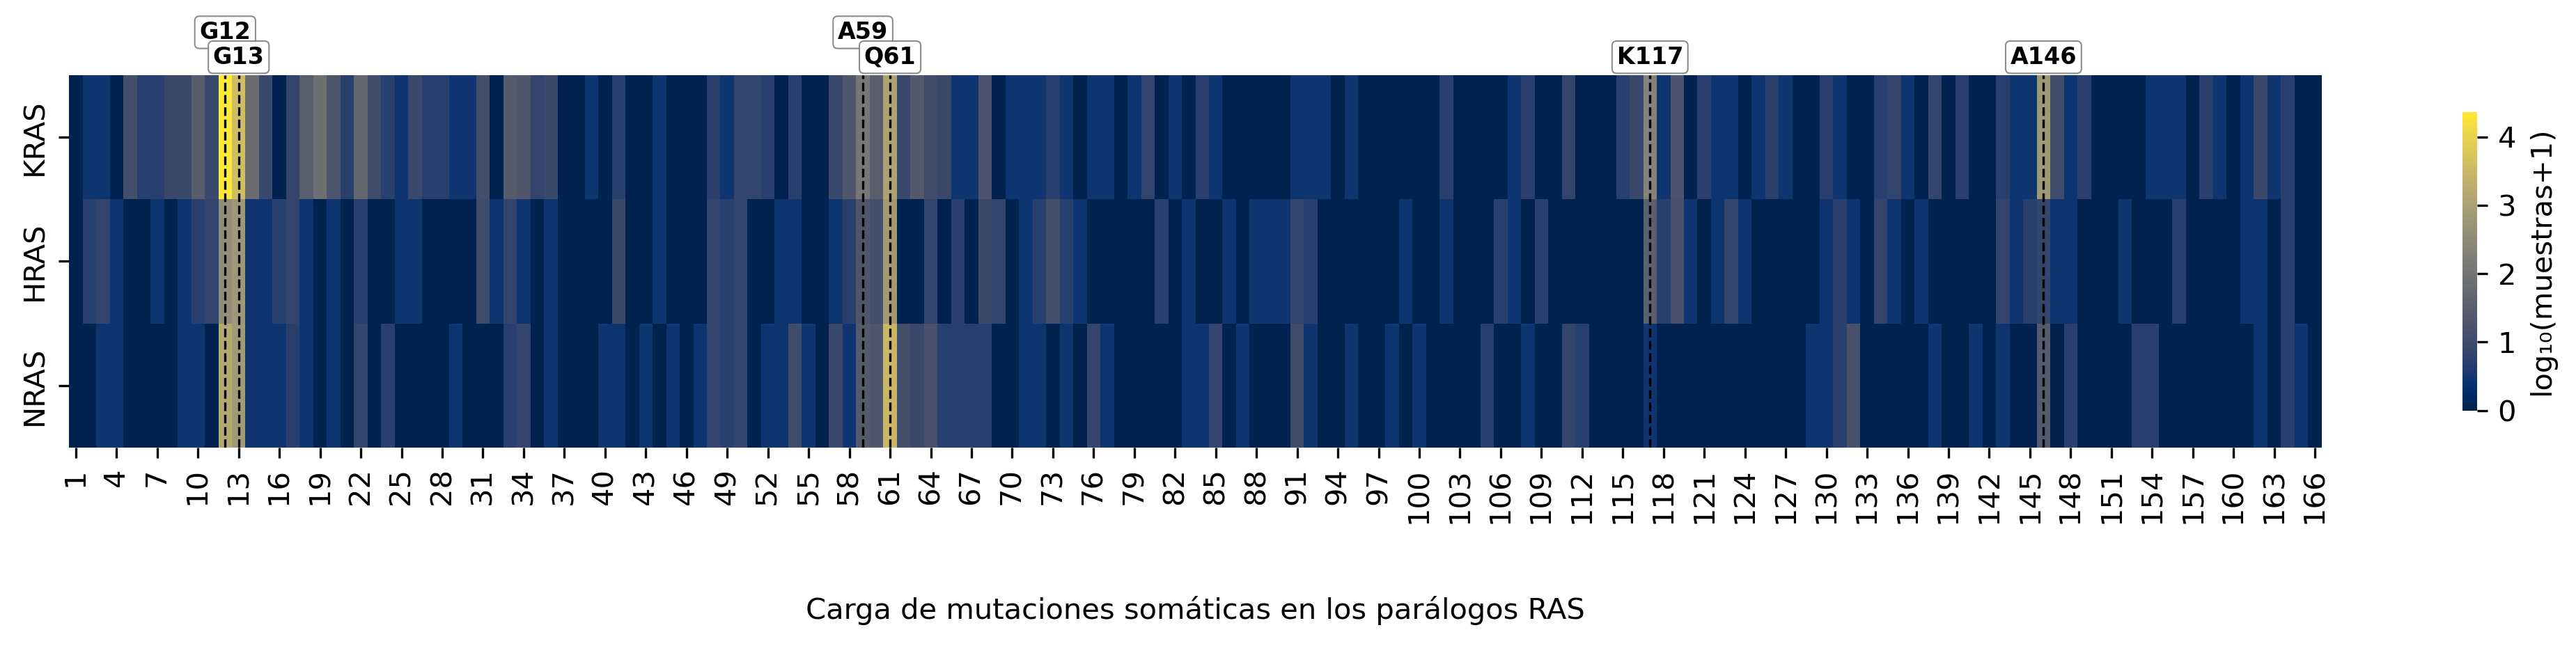

In [27]:
# ============================================================
# CHUNK 3.1: Heatmap de mutaciones por posición MSA
# ============================================================

# Definimos la ruta base de salida (sin extensión).
# heatmap_mutations_per_position() generará automáticamente los ficheros
# 04_heatmap_mutations.png y 04_heatmap_mutations.svg en esa ruta.
heatmap_basename = FIGURES_DIR / "04_heatmap_mutations"

# Llamamos a la función de visualización del módulo tfm_ras.
# Argumentos:
#   master_features → DataFrame maestro con columnas 'gene', 'msa_position', 'total_samples'
#   heatmap_basename → ruta base de salida (sin extensión)
#   figsize=(14, 3.2) → tamaño en pulgadas: panorámico para caber todas las posiciones
heatmap_paths = heatmap_mutations_per_position(
    master_features,
    heatmap_basename,
    figsize=(14, 3.2),   # 14 pulgadas de ancho × 3.2 de alto (aspecto panorámico)
)

# La función devuelve un diccionario {'png': Path, 'svg': Path} con las rutas generadas
print(f"PNG guardado en: {heatmap_paths['png']}")
print(f"SVG guardado en: {heatmap_paths['svg']}")

# Visualizamos la figura PNG inline en el notebook
# IPython.display.Image carga y muestra un fichero de imagen en la celda de salida
from IPython.display import Image
Image(str(heatmap_paths["png"]), width=900)

### 3.2 Clustermap de patrones de mutación más recurrentes

El clustermap aplica **agrupamiento jerárquico** (dendrograma) sobre las posiciones
más mutadas para revelar si existe estructura de bloques: posiciones que comparten
perfiles de incidencia similares entre los tres parálogos se agrupan juntas.

El agrupamiento de **columnas está desactivado** para mantener el orden fijo
KRAS > HRAS > NRAS y facilitar la comparación con el heatmap anterior.

PNG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_clustermap_patterns.png
SVG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_clustermap_patterns.svg


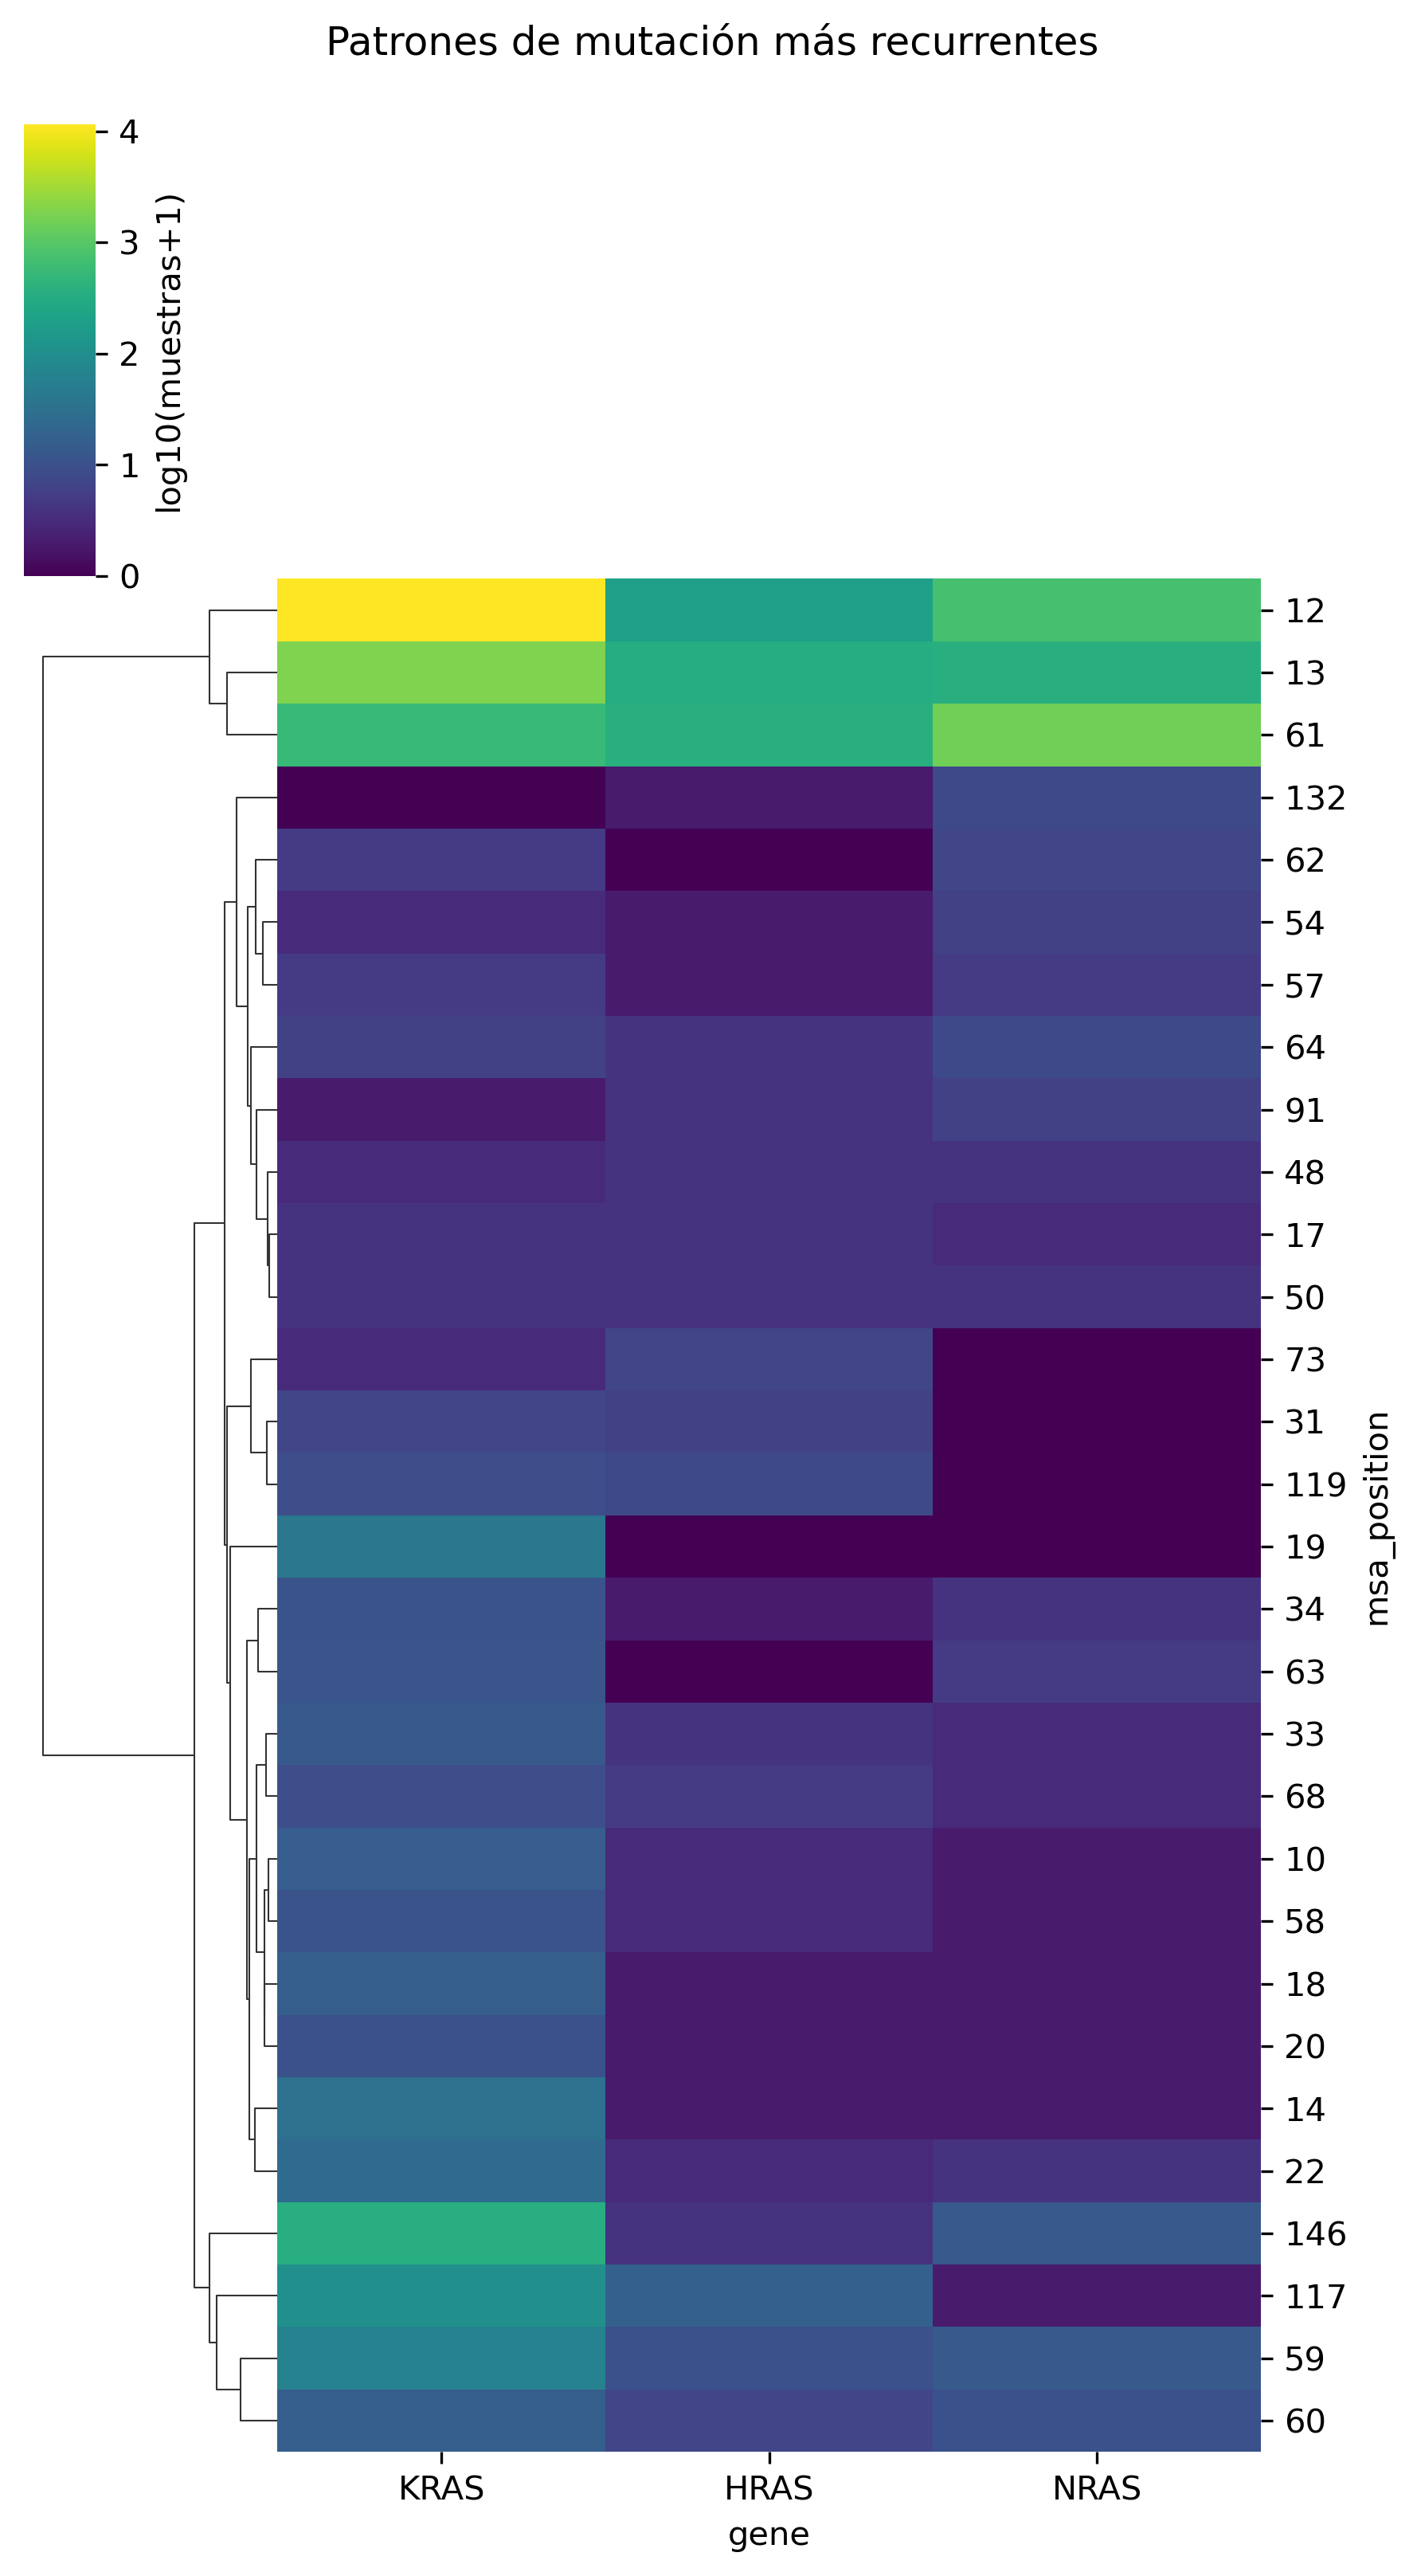

In [28]:
# ============================================================
# CHUNK 3.2: Clustermap de patrones de las top-30 posiciones
# ============================================================

# Definimos la ruta base de salida para el clustermap
clustermap_basename = FIGURES_DIR / "04_clustermap_patterns"

# Llamamos a la función de clustermap.
# Argumentos:
#   master_features    → DataFrame maestro con todos los datos
#   top_n=30           → número de posiciones más mutadas a incluir
#                        (30 es suficiente para ver el panorama sin saturar la figura)
#   output_basename    → ruta base de salida
clustermap_paths = clustermap_top_positions(
    master_features,
    top_n=30,
    output_basename=clustermap_basename,
)

print(f"PNG guardado en: {clustermap_paths['png']}")
print(f"SVG guardado en: {clustermap_paths['svg']}")

# Mostramos la figura inline en el notebook
Image(str(clustermap_paths["png"]), width=500)

### 3.3 Scatter: SASA relativa vs distancia al sitio activo

Esta figura relaciona dos propiedades estructurales de cada posición mutada:

- **Eje X — SASA relativa**: fracción de la superficie accesible al solvente
  (0 = completamente enterrado, 1 = completamente expuesto)
- **Eje Y — Distancia al sitio activo**: distancia en Ångströms al residuo
  del sitio activo más cercano
- **Tamaño del punto**: proporcional a log₁₀(muestras + 1)
- **Color del punto**: entropía de Shannon (conservación evolutiva de la posición)

Las líneas de referencia en SASA=0.25 y distancia=5.0 Å dividen el espacio
en cuatro cuadrantes.

PNG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_scatter_sasa_distance.png
SVG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_scatter_sasa_distance.svg


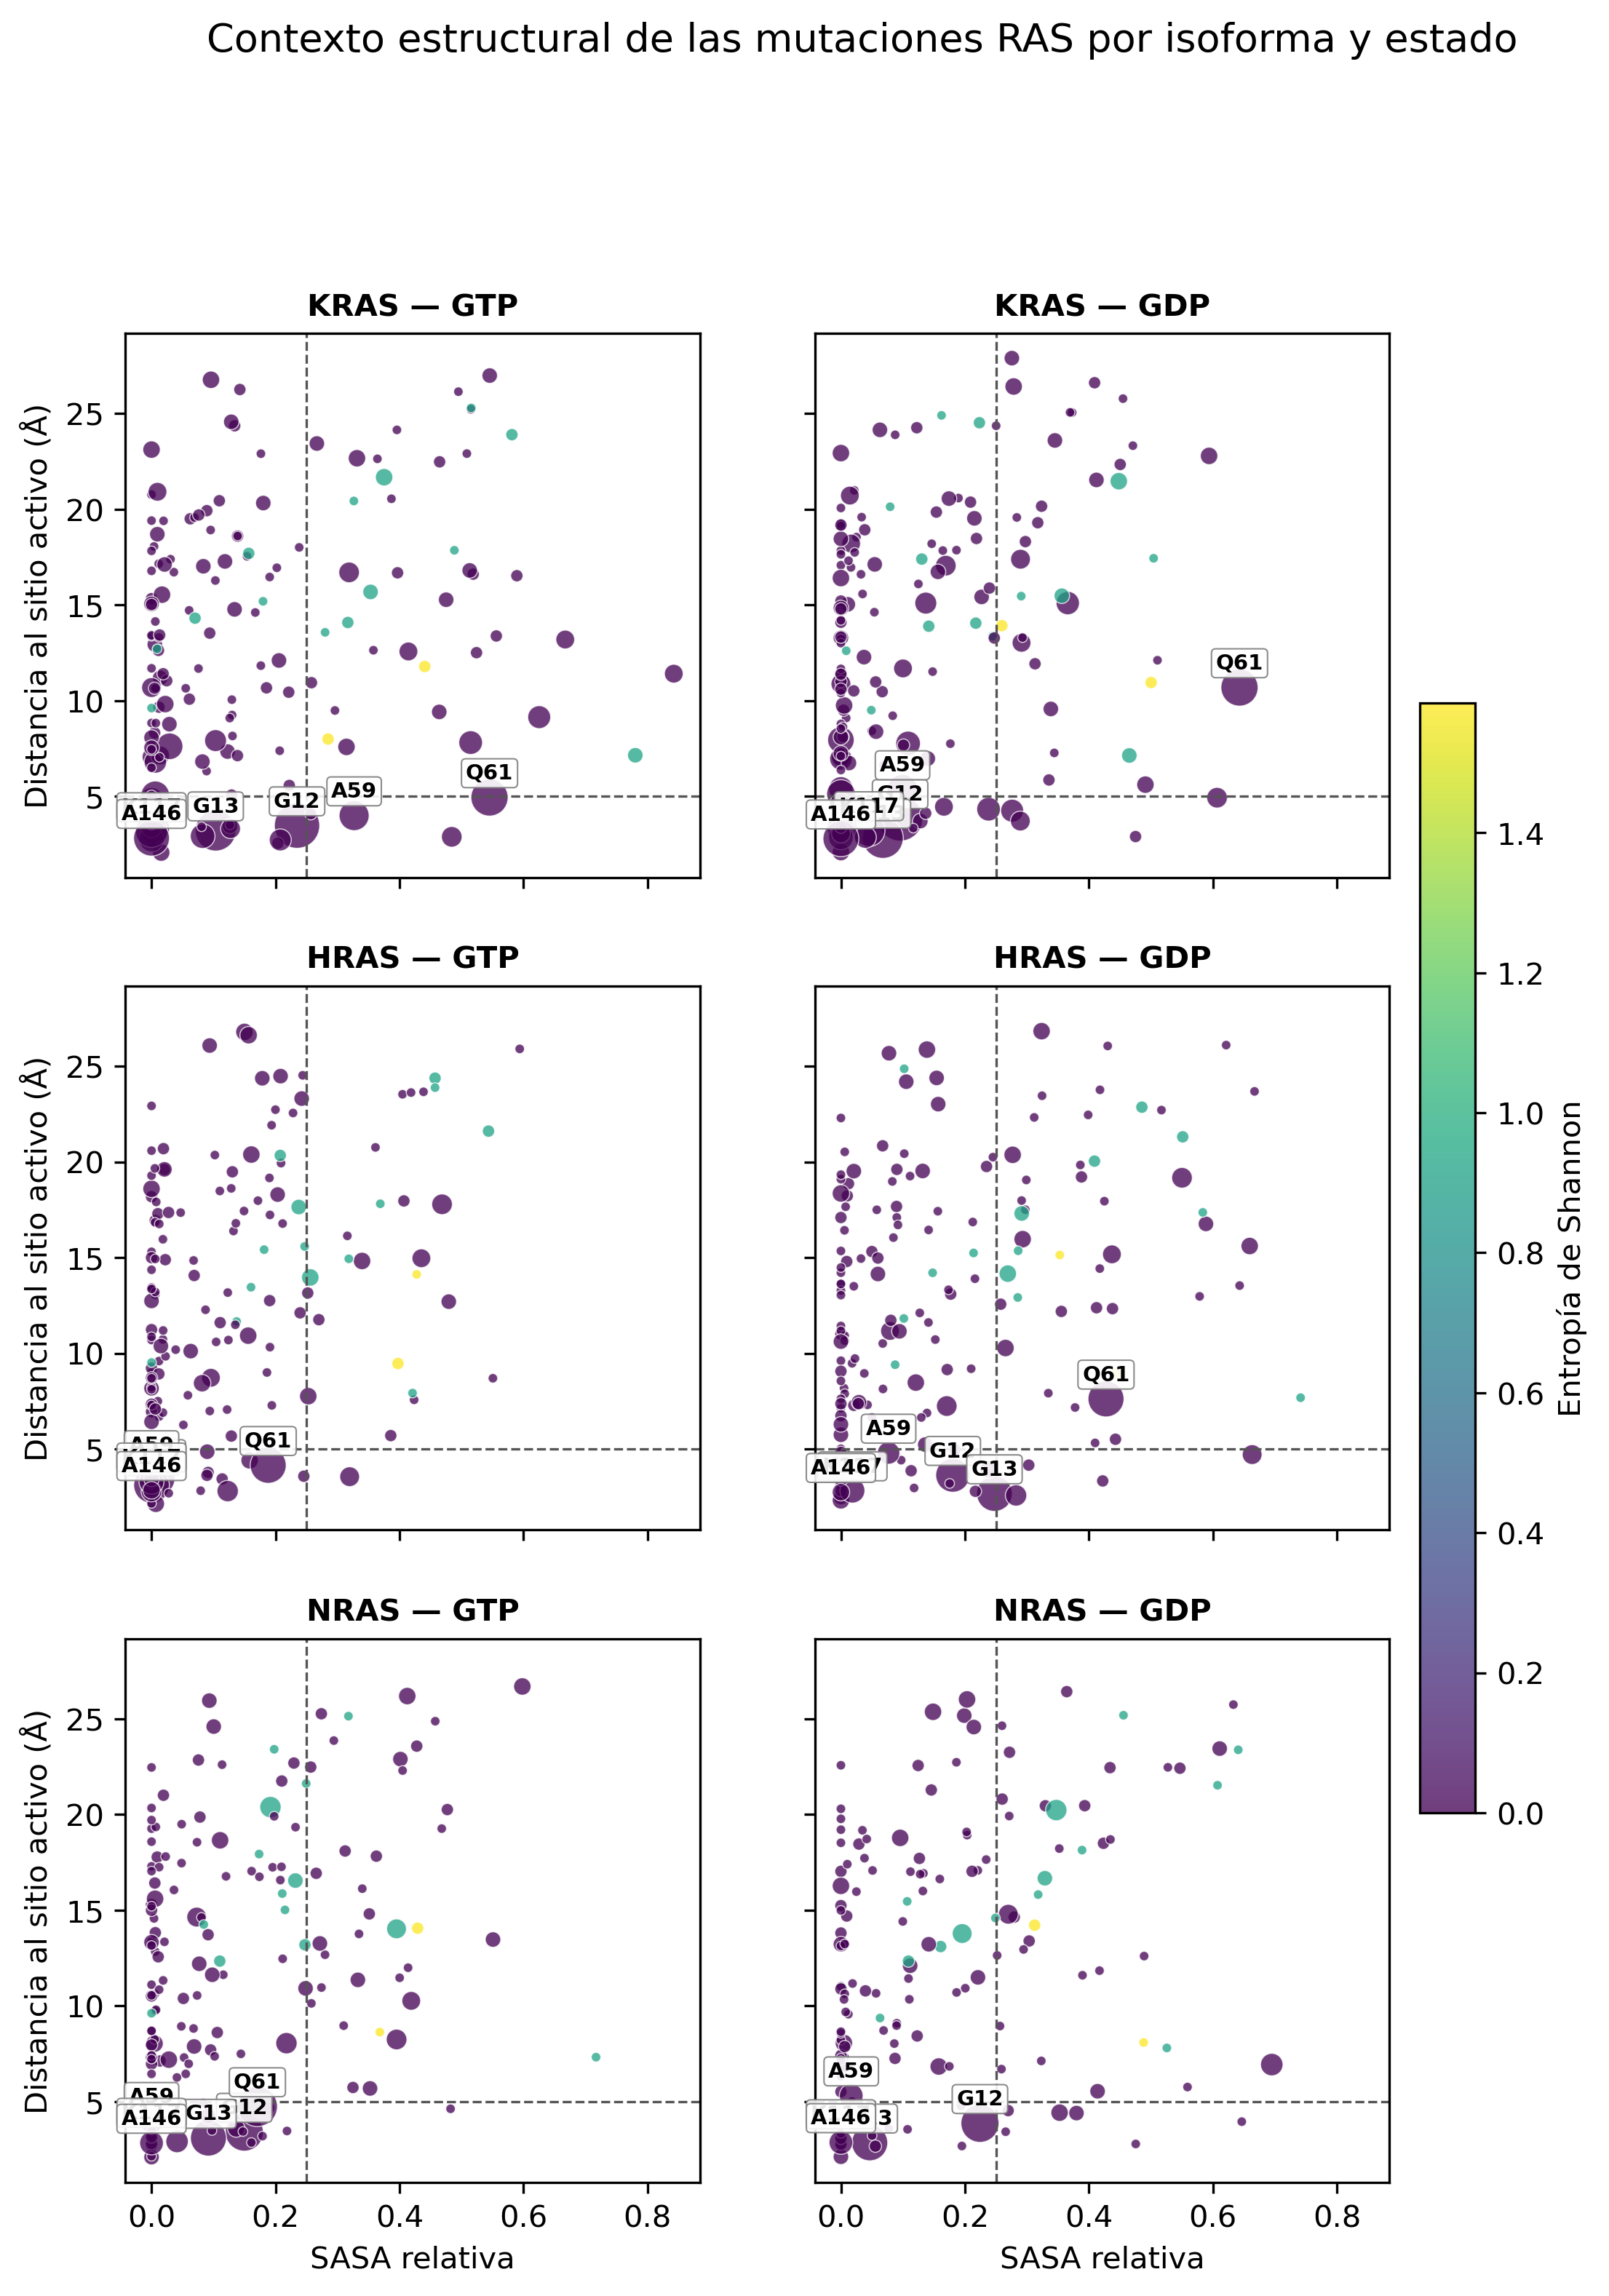

In [29]:
# ============================================================
# CHUNK 3.3: Scatter SASA relativa vs distancia al sitio activo
# ============================================================

# Ruta base para los ficheros de salida del scatter
scatter_basename = FIGURES_DIR / "04_scatter_sasa_distance"

# Generamos el scatter. La función requiere que master_features contenga:
#   'sasa_rel', 'dist_active_site_angstrom', 'total_samples',
#   'shannon_entropy', 'uniprot_position', 'gene', 'aa_wt'
scatter_paths = scatter_sasa_distance(
    master_features,
    scatter_basename,
)

print(f"PNG guardado en: {scatter_paths['png']}")
print(f"SVG guardado en: {scatter_paths['svg']}")

# Visualizamos inline
Image(str(scatter_paths["png"]), width=650)

---
## Sección 4: Vistas 3D interactivas con py3Dmol

### ¿Qué es py3Dmol y cómo funciona?

[py3Dmol](https://github.com/3dmol/3Dmol.js) es una librería Python que genera código
JavaScript para el visor molecular [3Dmol.js](https://3dmol.csb.pitt.edu/) basado en WebGL.

El flujo de trabajo es el siguiente:

1. Python crea un objeto `view = py3Dmol.view()` que actúa como constructor
2. Se añaden modelos moleculares con `view.addModel(pdb_text, "pdb")`
3. Se definen estilos de visualización con `view.setStyle()` y `view.addStyle()`
4. `view.write_html(path)` genera un fichero HTML auto-contenido con todo el
   JavaScript incrustado — no necesita servidor ni conexión a internet para abrirse

Los ficheros HTML resultantes pueden:
- Abrirse directamente en cualquier navegador moderno (Chrome, Firefox, Edge)
- Incluirse como **Figuras Suplementarias Interactivas** en la memoria digital del TFM
- Compartirse con el tribunal vía enlace o adjunto

### Estructuras utilizadas

| Gen | PDB ID | Ligando | Resolución |
|-----|--------|---------|------------|
| KRAS | 5UK9 | GCP | 1.89 Å |
| KRAS | 4OBE | GDP | 1.24 Å |
| HRAS | 3K8Y | GNP | 1.30 Å |
| HRAS | 4Q21 | GDP | 2.00 Å |
| NRAS | 5UHV | GNP | 1.67 Å |
| NRAS | 3CON | GDP | 1.65 Å |

In [30]:
# ===================================================================
# CHUNK 4.1: Representación 3D de las isoformas en estado GTP vs GDP
# ===================================================================

# Hotspots a marcar en las vistas 3D 
hotspots_gtp = master_features.query("state == 'GTP' and uniprot_position in @HOTSPOTS.keys()")
hotspots_gdp = master_features.query("state == 'GDP' and uniprot_position in @HOTSPOTS.keys()")

check = verify_structure_registry()
assert check["file_found"].all(), "Falta algún PDB en data/external/pdb/"
assert check["ca_domain_g"].gt(50).all(), "Alguna cadena tiene muy pocos residuos del dominio G"
assert check["ligand_matches_state"].all(), "Algún par gen/estado tiene el ligando equivocado"
check

,gene,state,pdb_id,chain,file_found,ca_domain_g,ligands_in_chain,ligand_matches_state
0,KRAS,GTP,5UK9,B,True,163,"[GCP, MG]",True
1,KRAS,GDP,4OBE,A,True,166,"[GDP, MG]",True
2,HRAS,GTP,3K8Y,A,True,166,"[GNP, MG]",True
3,HRAS,GDP,4Q21,A,True,166,"[GDP, MG]",True
4,NRAS,GTP,5UHV,A,True,166,"[GNP, MG]",True
5,NRAS,GDP,3CON,A,True,155,"[GDP, MG]",True


In [31]:
# ============================================================
# CHUNK 4.2: KRAS, GTP vs GDP
# ============================================================

gene = "KRAS"
entry = STRUCTURE_REGISTRY[gene]
gene_hotspots = hotspots_gtp.query("gene == @gene")

kras_gtp_html = FIGURES_DIR / "04_3d_view_kras_gtp.html"
kras_gdp_html = FIGURES_DIR / "04_3d_view_kras_gdp.html"
kras_states_html = FIGURES_DIR / "04_3d_view_kras_gtp_vs_gdp.html"

_, view_kras_gtp = view_3d_with_hotspots(
    entry["GTP"]["pdb_id"], gene_hotspots, kras_gtp_html,
    chain=entry["GTP"]["chain"],
)
_, view_kras_gdp = view_3d_with_hotspots(
    entry["GDP"]["pdb_id"], gene_hotspots, kras_gdp_html,
    chain=entry["GDP"]["chain"],
)
_, view_kras_states = compare_states_3d(
    gene, kras_states_html, hotspot_data=gene_hotspots,
)

print("↓ Vista interactiva inline:")

display(view_kras_gtp)
display(view_kras_gdp)
display(view_kras_states)



↓ Vista interactiva inline:


In [32]:
# ============================================================
# CHUNK 4.3: HRAS, GTP vs GDP
# ============================================================

gene = "HRAS"
entry = STRUCTURE_REGISTRY[gene]
gene_hotspots = hotspots_gtp.query("gene == @gene")

hras_gtp_html = FIGURES_DIR / "04_3d_view_hras_gtp.html"
hras_gdp_html = FIGURES_DIR / "04_3d_view_hras_gdp.html"
hras_states_html = FIGURES_DIR / "04_3d_view_hras_gtp_vs_gdp.html"

_, view_hras_gtp = view_3d_with_hotspots(
    entry["GTP"]["pdb_id"], gene_hotspots, hras_gtp_html,
    chain=entry["GTP"]["chain"],
)
_, view_hras_gdp = view_3d_with_hotspots(
    entry["GDP"]["pdb_id"], gene_hotspots, hras_gdp_html,
    chain=entry["GDP"]["chain"],
)
_, view_hras_states = compare_states_3d(
    gene, hras_states_html, hotspot_data=gene_hotspots,
)

print("↓ Vista interactiva inline:")

display(view_hras_gtp)
display(view_hras_gdp)
display(view_hras_states)


↓ Vista interactiva inline:


In [33]:
# ============================================================
# CHUNK 4.4: NRAS, GTP vs GDP
# ============================================================

gene = "NRAS"
entry = STRUCTURE_REGISTRY[gene]
gene_hotspots = hotspots_gtp.query("gene == @gene")

nras_gtp_html = FIGURES_DIR / "04_3d_view_nras_gtp.html"
nras_gdp_html = FIGURES_DIR / "04_3d_view_nras_gdp.html"
nras_states_html = FIGURES_DIR / "04_3d_view_nras_gtp_vs_gdp.html"

_, view_nras_gtp = view_3d_with_hotspots(
    entry["GTP"]["pdb_id"], gene_hotspots, nras_gtp_html,
    chain=entry["GTP"]["chain"],
)
_, view_nras_gdp = view_3d_with_hotspots(
    entry["GDP"]["pdb_id"], gene_hotspots, nras_gdp_html,
    chain=entry["GDP"]["chain"],
)
_, view_nras_states = compare_states_3d(
    gene, nras_states_html, hotspot_data=gene_hotspots,
)

print("↓ Vista interactiva inline:")

display(view_nras_gtp)
display(view_nras_gdp)
display(view_nras_states)

↓ Vista interactiva inline:


In [34]:
# ============================================================
# CHUNK 4.5: Comparación estructural isoformas estado GTP
# ============================================================

isoforms_gtp_html = FIGURES_DIR / "04_3d_view_isoforms_gtp.html"

_, view_isoforms_gtp = compare_isoforms_3d(
    "GTP", isoforms_gtp_html, hotspot_data=hotspots_gtp
)
view_isoforms_gtp

print("↓ Vista interactiva inline:")

display(view_isoforms_gtp)

↓ Vista interactiva inline:


In [35]:
# ============================================================
# CHUNK 4.6: Comparación estructural isoformas estado GDP
# ============================================================

isoforms_gdp_html = FIGURES_DIR / "04_3d_view_isoforms_gdp.html"

_, view_isoforms_gdp = compare_isoforms_3d(
    "GDP", isoforms_gdp_html, hotspot_data=hotspots_gdp
)
view_isoforms_gdp

print("↓ Vista interactiva inline:")
display(view_isoforms_gdp)

↓ Vista interactiva inline:


---
## Sección 5: Tablas de resultados

Esta sección construye las tres tablas principales de resultados del TFM.
Cada tabla tiene un propósito específico en la narrativa de la memoria:

| Tabla | Propósito | Nivel de análisis |
|-------|-----------|-------------------|
| `table_top_mutations.csv` | Ranking de mutaciones individuales más frecuentes con todas sus features | Mutación |
| `table_recurrent_summary.csv` | Resumen de posiciones recurrentes entre parálogos | Posición MSA |
| `table_isoform_specific.csv` | Posiciones donde un parálogo domina el perfil mutacional | Isoforma |

### 5.1 Tabla de top mutaciones (`table_top_mutations.csv`)

Esta tabla construye el **ranking de las mutaciones individuales más frecuentes**
integrando las features estructurales de `master_features` con los metadatos clínicos
de `cosmic_curated` (tipos de tumor y tejidos primarios).

La operación clave es un **merge** (join SQL) entre los dos DataFrames:
- `master_features` proporciona las features estructurales (SASA, distancia, entropía)
- `cosmic_curated` proporciona los metadatos clínicos (tumour_types, primary_tissues)

In [36]:
# ============================================================
# CHUNK 5.1: Construcción de table_top_mutations
# ============================================================

# Construimos la tabla de top mutaciones mediante un merge (join) entre
# master_features y cosmic_curated.

# Ruta de salida de la tabla
top_mutations_path = PROCESSED_DIR / "table_top_mutations.csv"

top_mutations = (
    master_features
    .loc[master_features["total_samples"].gt(0)]  # solo posiciones con mutaciones
    .merge(
        # Seleccionamos solo las columnas de cosmic_curated que necesitamos
        # para evitar columnas duplicadas y reducir el tamaño del merge
        cosmic_curated[["gene", "position", "hgvs_p", "tumor_types", "primary_tissues"]],
        # left_on: columnas de master_features usadas como clave de unión
        left_on=["gene", "uniprot_position"],
        # right_on: columnas de cosmic_curated usadas como clave de unión
        right_on=["gene", "position"],
        # how="left": conserva todas las filas del lado izquierdo (master_features)
        # aunque no tengan correspondencia en cosmic_curated (quedan como NaN)
        how="left",
    )
    .sort_values("total_samples", ascending=False)  # de más frecuente a menos
    # Renombramos columnas para mayor claridad:
    # hgvs_p → mutation (notación HGVS del cambio aminoacídico)
    # position_y → position (la posición de cosmic_curated; _y por el merge)
    .rename(columns={"hgvs_p": "mutation", "position_y": "position"})
    # Seleccionamos y reordenamos las columnas finales de la tabla
    [["gene", "uniprot_position", "mutation", "total_samples", "aa_wt",
      "sasa_rel", "dist_active_site_angstrom", "shannon_entropy",
      "recurrent", "n_members_mutated", "tumor_types", "primary_tissues"]]
    # Renombrado final para hacer los nombres de columna más descriptivos
    .rename(columns={"uniprot_position": "position", "aa_wt": "wt_aa"})
)

# Añadimos la columna mut_aa (aminoácido mutado) extrayéndola de la notación HGVS.
# Ejemplo: de "p.G12D" extraemos "D" (último carácter del cambio)
# La expresión regular r"p\.[A-Z]\d+([A-Z])$" captura:
#   p\.   → el prefijo literal "p."
#   [A-Z] → una letra mayúscula (aminoácido original)
#   \d+   → uno o más dígitos (número de posición)
#   ([A-Z])$ → capturamos la última letra mayúscula (aminoácido mutado)
# .str.extract() devuelve un DataFrame con los grupos capturados; [0] toma el primer grupo
top_mutations["mut_aa"] = top_mutations["mutation"].str.extract(r"p\.[A-Z]\d+([A-Z])$")

# Reordenamos las columnas para que mut_aa quede junto a wt_aa
top_mutations = top_mutations[
    ["gene", "position", "mutation", "total_samples", "wt_aa", "mut_aa",
     "sasa_rel", "dist_active_site_angstrom", "shannon_entropy",
     "recurrent", "n_members_mutated", "tumor_types", "primary_tissues"]
]

# Reiniciamos el índice para numeración consecutiva desde 0
top_mutations = top_mutations.reset_index(drop=True)

print(f"table_top_mutations: {len(top_mutations):,} filas × {top_mutations.shape[1]} columnas")
print(f"Columnas: {top_mutations.columns.tolist()}")

# Guardamos el DataFrame como CSV.
# index=False: no escribimos el índice numérico de pandas como columna adicional
# float_format="%.4f": formateamos los decimales a 4 cifras para SASA y distancia
top_mutations.to_csv(top_mutations_path, index=False, float_format="%.4f")

print(f"Tabla guardada en: {top_mutations_path}")
print(f"Tamaño del fichero: {top_mutations_path.stat().st_size / 1024:.1f} KB")

top_mutations.head(10)  # Mostramos las 10 mutaciones más frecuentes


table_top_mutations: 864 filas × 13 columnas
Columnas: ['gene', 'position', 'mutation', 'total_samples', 'wt_aa', 'mut_aa', 'sasa_rel', 'dist_active_site_angstrom', 'shannon_entropy', 'recurrent', 'n_members_mutated', 'tumor_types', 'primary_tissues']
Tabla guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/table_top_mutations.csv
Tamaño del fichero: 102.6 KB


,gene,position,mutation,total_samples,wt_aa,mut_aa,sasa_rel,dist_active_site_angstrom,shannon_entropy,recurrent,n_members_mutated,tumor_types,primary_tissues
0,KRAS,12,p.G12N,11564,G,N,0.095456,3.844901,-0.0,True,3,other,pancreas
1,KRAS,12,p.G12W,11564,G,W,0.095456,3.844901,-0.0,True,3,carcinoma,large_intestine
2,KRAS,12,p.G12S,11564,G,S,0.095456,3.844901,-0.0,True,3,adenoma | carcinoma | germ_cell_tumour | haema...,biliary_tract | breast | cervix | endometrium ...
3,KRAS,12,p.G12R,11564,G,R,0.095456,3.844901,-0.0,True,3,adenoma | carcinoid-endocrine_tumour | carcino...,NS | biliary_tract | bone | breast | central_n...
4,KRAS,12,p.G12A,11564,G,A,0.095456,3.844901,-0.0,True,3,aberrant_crypt_foci | adenoma | carcinoid-endo...,NS | autonomic_ganglia | biliary_tract | breas...
5,KRAS,12,p.G12C,11564,G,C,0.095456,3.844901,-0.0,True,3,aberrant_crypt_foci | adenoma | angiosarcoma |...,NS | biliary_tract | breast | cervix | endomet...
6,KRAS,12,p.G12V,11564,G,V,0.095456,3.844901,-0.0,True,3,Wilms_tumour | aberrant_crypt_foci | adenoma |...,NS | autonomic_ganglia | biliary_tract | breas...
7,KRAS,12,p.G12I,11564,G,I,0.095456,3.844901,-0.0,True,3,carcinoma | malignant_melanoma,pancreas | skin
8,KRAS,12,p.G12L,11564,G,L,0.095456,3.844901,-0.0,True,3,carcinoma,large_intestine | pancreas
9,KRAS,12,p.G12F,11564,G,F,0.095456,3.844901,-0.0,True,3,carcinoma | other,breast | large_intestine | lung


### 5.2 Tabla de resumen de posiciones recurrentes (`table_recurrent_summary.csv`)

Esta tabla condensa la información de las **posiciones recurrentemente mutadas en
≥2 parálogos**, añadiendo las features estructurales medias para cada posición.

La operación clave es un **groupby + agg** sobre `master_features`:
- `groupby("msa_position")` agrupa todas las filas de la misma posición MSA
  (una por gen: KRAS, HRAS, NRAS)
- `agg()` calcula estadísticos resumen (media) de cada feature numérica
  para el conjunto de los tres parálogos en esa posición

In [37]:
# ============================================================
# CHUNK 5.2: Construcción de table_recurrent_summary
# ============================================================

# Ruta de salida de la tabla
recurrent_summary_path = PROCESSED_DIR / "table_recurrent_summary.csv"

# Calculamos las features medias por posición MSA sobre master_features.
# groupby("msa_position") divide el DataFrame en grupos, uno por posición MSA.
# Cada grupo contiene típicamente 3 filas (una por gen: KRAS, HRAS, NRAS).

features_by_position = (
    master_features
    .groupby("msa_position")  # agrupa por posición del alineamiento
    .agg(
        # mean_sasa_rel: SASA relativa media entre los tres parálogos en esa posición
        mean_sasa_rel=("sasa_rel", "mean"),
        # mean_dist_active_site_angstrom: distancia media al sitio activo entre parálogos
        mean_dist_active_site_angstrom=("dist_active_site_angstrom", "mean"),
        # mean_shannon_entropy: entropía de Shannon media (conservación evolutiva)
        mean_shannon_entropy=("shannon_entropy", "mean"),
    )
    .reset_index()  # convierte msa_position de índice a columna regular
)

# Aquí unimos las dos tablas por la columna común "msa_position".
# how="left": conservamos todas las posiciones recurrentes aunque no tengan
# features calculadas (aunque en la práctica siempre deberían tenerlas).
recurrent_with_features = (
    recurrent_positions
    .merge(
        features_by_position,  # features medias por posición calculadas en el paso anterior
        on="msa_position",     # columna común de unión (misma clave en ambas tablas)
        how="left",            # conserva todas las filas de recurrent_positions
    )
)


# Usamos apply() con una función lambda row que itera sobre los tres genes
# y comprueba si su columna de muestras supera el umbral.
# pd.notna(row[f"{g.lower()}_samples"]): verifica que el valor no es NaN
# row[f"{g.lower()}_samples"] >= 10: verifica que tiene ≥10 muestras
# "|".join(...): une los nombres de los genes con '|' como separador
recurrent_with_features["genes"] = recurrent_with_features.apply(
    lambda row: "|".join(
        g for g in ["KRAS", "HRAS", "NRAS"]
        if pd.notna(row[f"{g.lower()}_samples"]) and row[f"{g.lower()}_samples"] >= 10
    ),
    axis=1,  # axis=1: aplica la función por fila (no por columna)
)

# PASO 4: Seleccionamos y reordenamos las columnas finales de la tabla
table_recurrent = recurrent_with_features[[
    "msa_position",                   # posición en el alineamiento MSA
    "n_members_mutated",              # número de parálogos con mutaciones (2 o 3)
    "total_samples",                  # suma de muestras en los tres parálogos
    "genes",                          # parálogos con ≥10 muestras (p. ej. "KRAS|HRAS")
    "mean_sasa_rel",                  # SASA relativa media entre parálogos
    "mean_dist_active_site_angstrom", # distancia media al sitio activo
    "mean_shannon_entropy",           # entropía de Shannon media
    "top_mutations",                  # mutaciones más frecuentes (del CSV de recurrentes)
]].reset_index(drop=True)  # índice consecutivo desde 0

print(f"table_recurrent_summary: {len(table_recurrent):,} posiciones recurrentes")
print(f"Posiciones con los 3 parálogos: {table_recurrent['n_members_mutated'].eq(3).sum()}")

# Guardamos la tabla como CSV
table_recurrent.to_csv(recurrent_summary_path, index=False, float_format="%.4f")

print(f"Tabla guardada en: {recurrent_summary_path}")
print(f"Tamaño del fichero: {recurrent_summary_path.stat().st_size / 1024:.1f} KB")

table_recurrent.head(10)

table_recurrent_summary: 6 posiciones recurrentes
Posiciones con los 3 parálogos: 3
Tabla guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/table_recurrent_summary.csv
Tamaño del fichero: 0.6 KB


,msa_position,n_members_mutated,total_samples,genes,mean_sasa_rel,mean_dist_active_site_angstrom,mean_shannon_entropy,top_mutations
0,12,3,12487,KRAS|HRAS|NRAS,0.149112,3.612182,0.0,KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
1,13,3,2604,KRAS|HRAS|NRAS,0.092825,2.955898,0.0,KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
2,61,3,2424,KRAS|HRAS|NRAS,0.394879,6.425497,0.0,KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
3,146,2,361,KRAS|NRAS,0.000000,2.812793,0.0,KRAS:p.A146T|NRAS:p.A146T
4,117,2,121,KRAS|HRAS,0.010633,3.116772,0.0,KRAS:p.K117N|HRAS:p.K117N
5,59,2,81,KRAS|NRAS,0.086603,4.557887,0.0,KRAS:p.A59T|NRAS:p.A59T


### 5.3 Tabla de posiciones con dominancia de isoforma (`table_isoform_specific.csv`)

Esta tabla identifica las **posiciones donde un único parálogo concentra más del 60%
de las muestras totales** de esa posición recurrente. Estas posiciones tienen interés
biológico porque sugieren que la preferencia de mutación en esa posición es específica
de isoforma: puede reflejar diferencias en la accesibilidad estructural, en los patrones
de señalización downstream, o en el contexto tisular de cada parálogo.

In [38]:
# ============================================================
# CHUNK 5.3: Construcción de table_isoform_specific
# ============================================================

# Identificamos las posiciones donde un único parálogo domina

# Ruta de salida de la tabla
isoform_path = PROCESSED_DIR / "table_isoform_specific.csv"

isoform_data = []  # Lista acumuladora de registros; se convertirá en DataFrame al final

# Iteramos sobre cada fila de recurrent_positions.
# .iterrows() devuelve pares (índice, Series) con los datos de cada posición.
# Usamos iterrows() porque necesitamos acceder a múltiples columnas de cada fila
# y la lógica condicional dentro del bucle no es fácilmente vectorizable.
for _, row in recurrent_positions.iterrows():
    total = row["total_samples"]  # Total de muestras en todos los parálogos

    # Si no hay muestras (total = 0), no tiene sentido calcular la ratio dominante
    if total == 0:
        continue  # Pasamos a la siguiente fila sin añadir registro

    # Comprobamos cada uno de los tres parálogos
    for gene in ["kras", "hras", "nras"]:
        # Accedemos a la columna de muestras del gen (p. ej. "kras_samples")
        samples = row[f"{gene}_samples"]

        # Calculamos la fracción que representa este gen del total de muestras
        ratio = samples / total  # valor entre 0.0 y 1.0

        # Solo incluimos la entrada si el gen domina (>60% de las muestras)
        if ratio > 0.6:
            # Construimos el registro con los campos de la tabla final
            isoform_data.append({
                "msa_position": row["msa_position"],       # posición en el MSA
                "dominant_gene": gene.upper(),             # gen dominante en mayúsculas (KRAS, HRAS, NRAS)
                "dominant_ratio": round(ratio, 3),        # fracción dominante (3 decimales)
                "total_samples": total,                    # muestras totales en esa posición
                "kras_samples": row["kras_samples"],       # muestras KRAS en esa posición
                "hras_samples": row["hras_samples"],       # muestras HRAS en esa posición
                "nras_samples": row["nras_samples"],       # muestras NRAS en esa posición
            })


table_isoform = pd.DataFrame(isoform_data, columns=[
    "msa_position",    # posición en el alineamiento múltiple
    "dominant_gene",   # gen que domina en esa posición (>60% de muestras)
    "dominant_ratio",  # fracción de muestras del gen dominante (0–1)
    "total_samples",   # suma de muestras de todos los parálogos en esa posición
    "kras_samples",    # muestras de KRAS en esa posición
    "hras_samples",    # muestras de HRAS en esa posición
    "nras_samples",    # muestras de NRAS en esa posición
])

# Ordenamos por gen dominante y luego por total de muestras descendente
# para facilitar la lectura en la memoria del TFM
table_isoform = (
    table_isoform
    .sort_values(["dominant_gene", "total_samples"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"table_isoform_specific: {len(table_isoform):,} posiciones con dominancia de isoforma")
if len(table_isoform) > 0:
    # Contamos cuántas posiciones domina cada gen
    print("\nDistribución por gen dominante:")
    print(table_isoform["dominant_gene"].value_counts().to_string())
else:
    print("(No se encontraron posiciones con dominancia >60% en ningún parálogo)")

# Guardamos la tabla como CSV
table_isoform.to_csv(isoform_path, index=False, float_format="%.4f")

print(f"Tabla guardada en: {isoform_path}")
print(f"Tamaño del fichero: {isoform_path.stat().st_size / 1024:.1f} KB")

table_isoform.head(10)

table_isoform_specific: 6 posiciones con dominancia de isoforma

Distribución por gen dominante:
dominant_gene
KRAS    5
NRAS    1
Tabla guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/table_isoform_specific.csv
Tamaño del fichero: 0.3 KB


,msa_position,dominant_gene,dominant_ratio,total_samples,kras_samples,hras_samples,nras_samples
0,12,KRAS,0.926,12487,11564,195,728
1,13,KRAS,0.736,2604,1917,323,364
2,146,KRAS,0.958,361,346,3,12
3,117,KRAS,0.860,121,104,16,1
4,59,KRAS,0.741,81,60,9,12
5,61,NRAS,0.626,2424,542,365,1517


---
## Resumen del Hito 4

Esta sección imprime un inventario completo de todos los ficheros generados por
este notebook, organizado por tipo de salida.

In [39]:
# ============================================================
# CHUNK 7.1: Inventario de ficheros generados
# ============================================================

print("=" * 65)
print("INVENTARIO DE FICHEROS GENERADOS — HITO 4")
print("=" * 65)

# Diccionario con todas las salidas agrupadas por categoría
outputs = {
    "Figuras 2D (PNG + SVG)": [
        FIGURES_DIR / "04_heatmap_mutations.png",
        FIGURES_DIR / "04_heatmap_mutations.svg",
        FIGURES_DIR / "04_clustermap_patterns.png",
        FIGURES_DIR / "04_clustermap_patterns.svg",
        FIGURES_DIR / "04_scatter_sasa_distance.png",
        FIGURES_DIR / "04_scatter_sasa_distance.svg",
    ],
    "Vistas 3D interactivas (HTML)": [
        FIGURES_DIR / "04_3d_view_kras_gdp.html",
        FIGURES_DIR / "04_3d_view_kras_gtp.html",
        FIGURES_DIR / "04_3d_view_hras_gdp.html",
        FIGURES_DIR / "04_3d_view_hras_gtp.html",
        FIGURES_DIR / "04_3d_view_nras_gdp.html",
        FIGURES_DIR / "04_3d_view_nras_gtp.html",
        FIGURES_DIR / "04_3d_view_kras_gtp_vs_gdp.html",
        FIGURES_DIR / "04_3d_view_hras_gtp_vs_gdp.html",
        FIGURES_DIR / "04_3d_view_nras_gtp_vs_gdp.html",
        FIGURES_DIR / "04_3d_view_isoforms_gtp.html",
        FIGURES_DIR / "04_3d_view_isoforms_gdp.html",
    ],
    "Tablas de resultados (CSV)": [
        PROCESSED_DIR / "table_top_mutations.csv",
        PROCESSED_DIR / "table_recurrent_summary.csv",
        PROCESSED_DIR / "table_isoform_specific.csv",
    ],
}

# Iteramos sobre cada categoría y verificamos la existencia de cada fichero
for category, paths in outputs.items():
    print(f"\n{category}:")
    for path in paths:
        # path.exists() verifica si el fichero existe en disco
        exists = path.exists()
        # Si existe, mostramos también el tamaño en KB
        size_str = f" ({path.stat().st_size / 1024:.1f} KB)" if exists else ""
        status = "OK" if exists else "FALTA"
        print(f"  [{status}] {path.name}{size_str}")

print("\n" + "=" * 65)
print("HITO 4 COMPLETADO")
print("El pipeline completo ha finalizado exitosamente.")
print("=" * 65)

INVENTARIO DE FICHEROS GENERADOS — HITO 4

Figuras 2D (PNG + SVG):
  [OK] 04_heatmap_mutations.png (111.2 KB)
  [OK] 04_heatmap_mutations.svg (158.1 KB)
  [OK] 04_clustermap_patterns.png (123.7 KB)
  [OK] 04_clustermap_patterns.svg (65.2 KB)
  [OK] 04_scatter_sasa_distance.png (636.5 KB)
  [OK] 04_scatter_sasa_distance.svg (792.0 KB)

Vistas 3D interactivas (HTML):
  [OK] 04_3d_view_kras_gdp.html (744.6 KB)
  [OK] 04_3d_view_kras_gtp.html (277.2 KB)
  [OK] 04_3d_view_hras_gdp.html (160.3 KB)
  [OK] 04_3d_view_hras_gtp.html (171.6 KB)
  [OK] 04_3d_view_nras_gdp.html (160.6 KB)
  [OK] 04_3d_view_nras_gtp.html (156.8 KB)
  [OK] 04_3d_view_kras_gtp_vs_gdp.html (693.6 KB)
  [OK] 04_3d_view_hras_gtp_vs_gdp.html (245.9 KB)
  [OK] 04_3d_view_nras_gtp_vs_gdp.html (229.9 KB)
  [OK] 04_3d_view_isoforms_gtp.html (476.7 KB)
  [OK] 04_3d_view_isoforms_gdp.html (689.2 KB)

Tablas de resultados (CSV):
  [OK] table_top_mutations.csv (102.6 KB)
  [OK] table_recurrent_summary.csv (0.6 KB)
  [OK] table_is